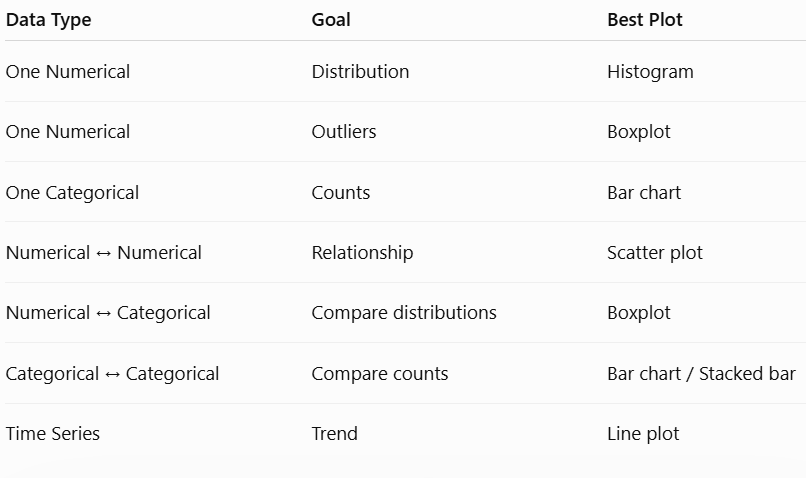

## Import the Libraries

In [378]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split

# Display pandas DataFrames more nicely
pd.set_option("display.max_columns", None)

## Loading the Data

In [379]:
train_df = pd.read_csv('../Data/train.csv')
test_df = pd.read_csv('../Data/test.csv')

## Exploratory Data Analysis (EDA)

#### Step 1: Look at the First Few Rows

In [380]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [381]:
train_df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


#### Step 2: Understand the Shape

In [382]:
train_df.shape

(891, 12)

#### Step 3: List the Columns

In [383]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

* There are 891 rows and 12 columns in the train_df dataset
* Numeric columns: `PassengerId, Age, SibSp, ParCh, Fare`
* Categorical columns: `Name (nominal), Sex (nominal), Cabin, Embarked (nominal)`
* `Pclass` is numerical but in categorical in class
* `Survived` column is our `Target` column
* We can drop the `PassengerId` column, since it is a person identification column. It does not help in prediction
* We can also drop `Name and Cabin` columns since they have no role in prediction
* Rest of the cloumns are being used as our `Features`
------------------------------------------------------------------------------

#### Step 4: Information about the Columns

In [384]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Step 5: Statistical Summary

In [385]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Step 6: Missing Values

In [386]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Visual Exploratory Data Analysis (Visual EDA)

#### Step 1: Understand the Target Variable

In [387]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

#### Step 2: Visualize the Target

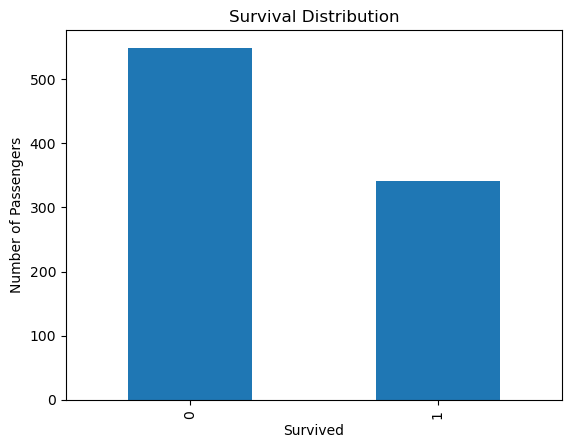

In [388]:
train_df['Survived'].value_counts().plot(kind='bar')

plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')

plt.show()

#### Step 3: Examine Age

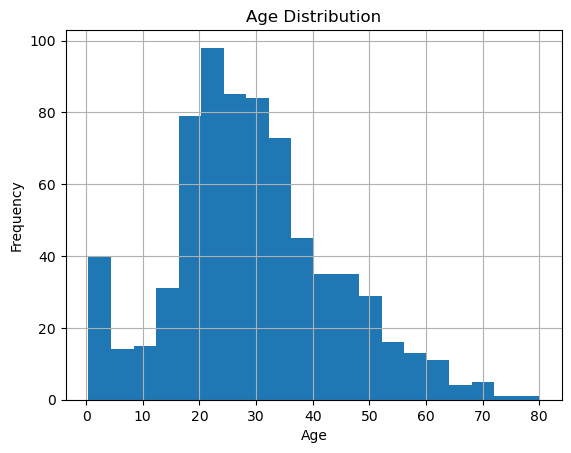

In [389]:
train_df['Age'].hist(bins = 20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

#### Relationship with Survival

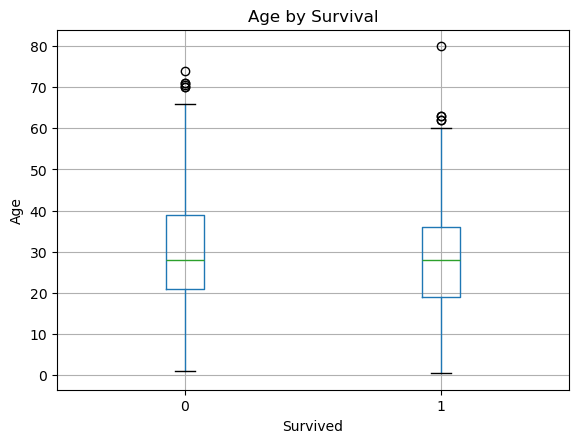

In [390]:
train_df.boxplot(column='Age', by='Survived')

plt.suptitle("")
plt.title('Age by Survival')
plt.xlabel('Survived')
plt.ylabel('Age')

plt.show()

#### Step 4: Examine Fare

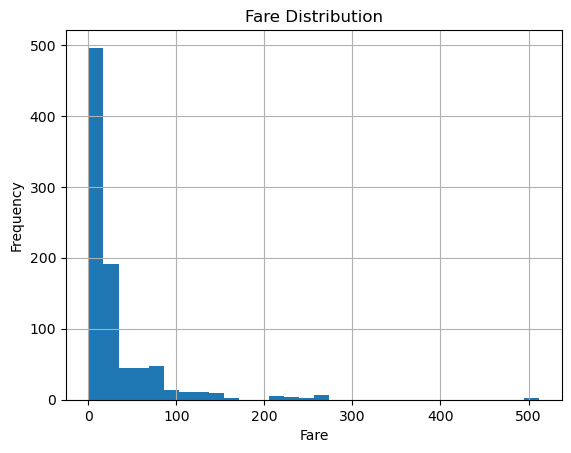

In [391]:
train_df['Fare'].hist(bins=30)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

#### Relationship with Survival

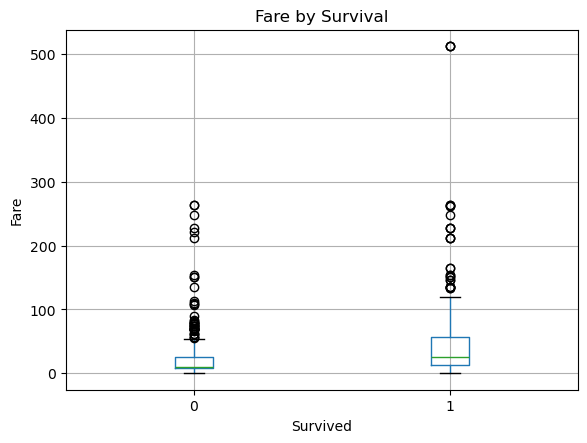

In [392]:
train_df.boxplot(column='Fare', by='Survived')

plt.suptitle('')
plt.title('Fare by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')

plt.show()

#### Step 5: Explore Sex

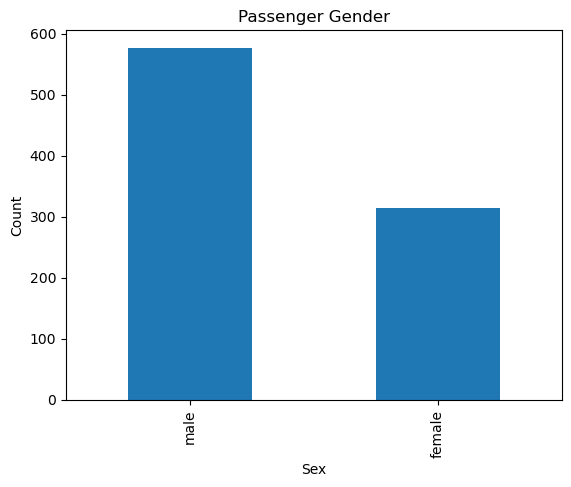

In [393]:
train_df['Sex'].value_counts().plot(kind='bar')

plt.title('Passenger Gender')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

#### Relationship Between Sex and Survival

In [394]:
pd.crosstab(train_df['Sex'], train_df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


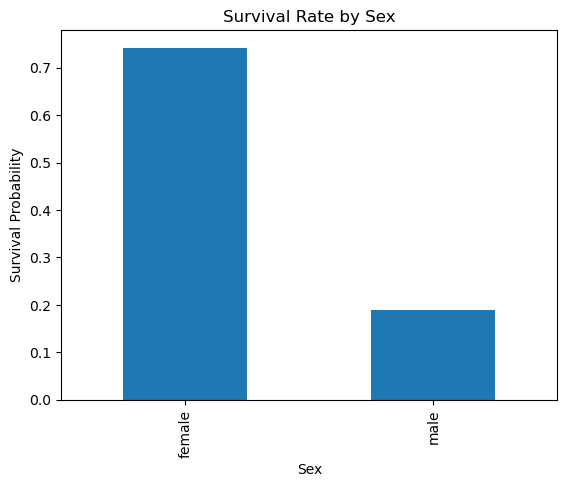

In [395]:
# survival rate 
train_df.groupby('Sex')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Sex')
plt.ylabel('Survival Probability')
plt.show()

#### Step 6: Explore Pclass

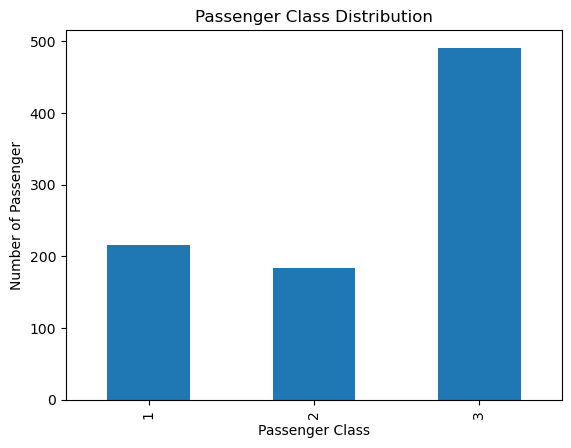

In [396]:
train_df['Pclass'].value_counts().sort_index().plot(kind='bar')

plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passenger')

plt.show()

#### Relationship with Survival

In [397]:
pd.crosstab(train_df['Pclass'], train_df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


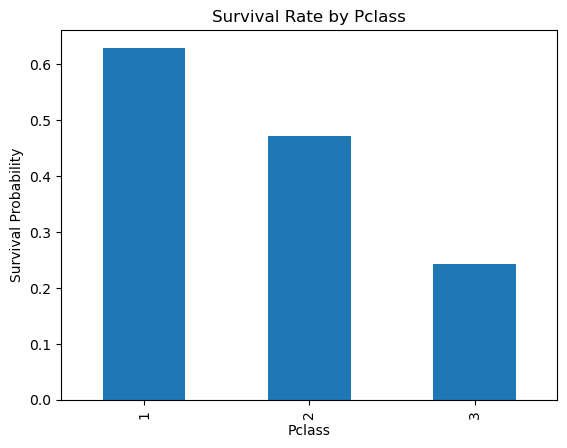

In [398]:
# survival rate
train_df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Pclass')
plt.ylabel('Survival Probability')
plt.show()

#### Step 7: Explore Embarked

In [399]:
train_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

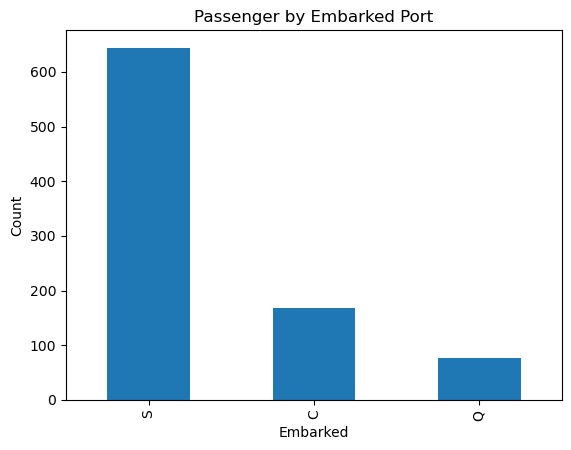

In [400]:
train_df['Embarked'].value_counts().plot(kind='bar')

plt.title('Passenger by Embarked Port')
plt.xlabel('Embarked')
plt.ylabel('Count')

plt.show()

#### Relationship with Survival

In [401]:
pd.crosstab(train_df['Embarked'], train_df['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


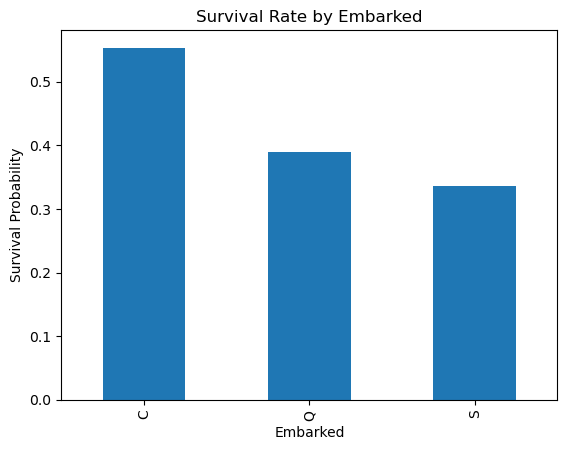

In [402]:
train_df.groupby('Embarked')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Embarked')
plt.xlabel('Embarked')
plt.ylabel('Survival Probability')

plt.show()

#### Step 8: Explore SibSp

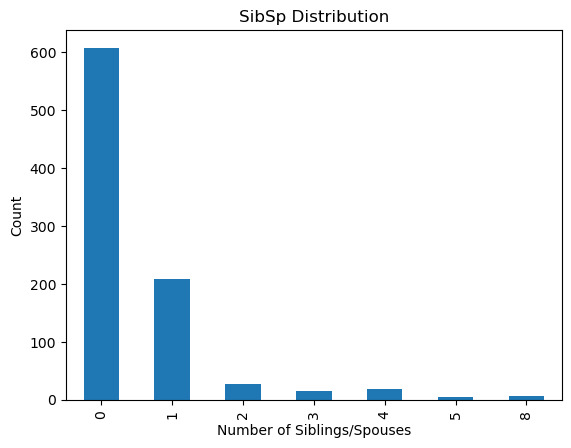

In [403]:
train_df['SibSp'].value_counts().sort_index().plot(kind='bar')

plt.title('SibSp Distribution')
plt.xlabel('Number of Siblings/Spouses')
plt.ylabel('Count')

plt.show()

In [404]:
pd.crosstab(train_df['SibSp'], train_df['Survived'])

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


In [405]:
# survival rate
train_df.groupby('SibSp')['Survived'].mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

#### Step 9: Explore ParCh

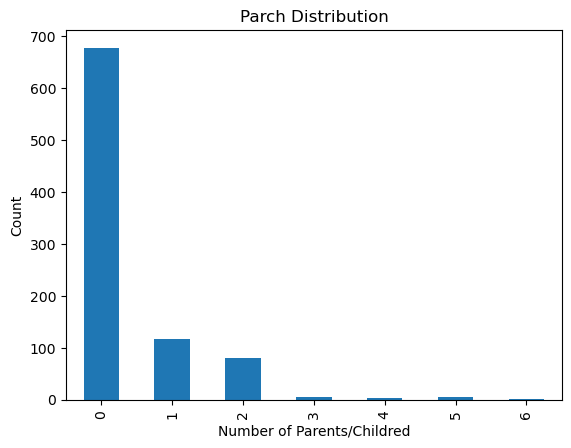

In [406]:
train_df['Parch'].value_counts().sort_index().plot(kind='bar')

plt.title('Parch Distribution')
plt.xlabel('Number of Parents/Childred')
plt.ylabel('Count')

plt.show()

#### Relationship with Survival

In [407]:
pd.crosstab(train_df['Parch'], train_df['Survived'])

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


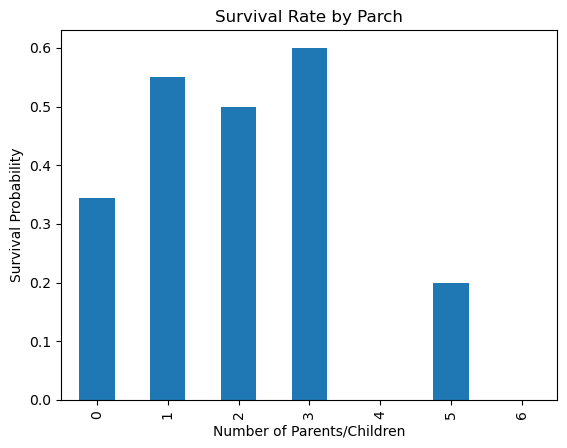

In [408]:
train_df.groupby('Parch')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Parch')
plt.xlabel('Number of Parents/Children')
plt.ylabel('Survival Probability')

plt.show()

## Build the Pipeline

In [409]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

#### Define Feature Groups

In [410]:
# Numerical Features
numeric_features = [
    'Age',
    'Fare',
    'SibSp',
    'Parch',
]

# Categorical Features
categorical_features  = [
    'Sex',
    'Embarked',
    'Pclass',
]

#### Building Numeric Pipeline

In [411]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#### Building Categorical Pipeline

In [412]:
# For learning purpose to see how OneHotEncoder works we skipped drop = 'first'
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#### Create the ColumnTransformer

In [413]:
preprocessor = ColumnTransformer(
    transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
    ])

#### Split Before Preprocessing

In [414]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns='Survived')
y = train_df['Survived']

X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2, random_state = 42, stratify=y)

In [415]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(712, 11)
(179, 11)
(712,)
(179,)


#### The Final Pipeline

In [416]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

#### Fit the Model

In [417]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('classifier', LogisticRegression())])

In [418]:
y_pred = model.predict(X_valid)

#### Evaluation Metric: Accuracy

In [419]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print(accuracy)
print(f'{accuracy * 100:.2f}% of validation passengers were classified correctly')

0.8044692737430168
80.45% of validation passengers were classified correctly


#### Classification Report

In [420]:
from sklearn.metrics import classification_report

print(classification_report(y_valid,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## Understanding Model Performance

#### Confusion Matrix

[[98 12]
 [23 46]]


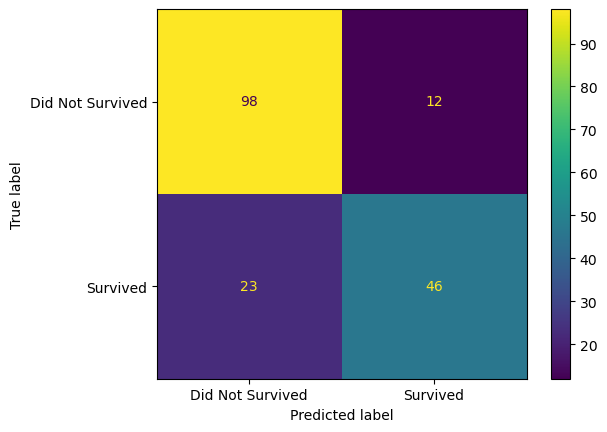

In [421]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_valid, y_pred)
print(cm)

labels = ['Did Not Survived', 'Survived'] 
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels).plot()
plt.show()

#### Check Class Distribution

In [422]:
pd.DataFrame(y).value_counts()

Survived
0           549
1           342
Name: count, dtype: int64

#### Check the Model for Underfittin or Overfitting

In [423]:
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

print(f"Training Accuracy {accuracy_score(y_train, train_pred)}")
print(f"Validation Accuracy {accuracy_score(y_valid,valid_pred)}")

Training Accuracy 0.8103932584269663
Validation Accuracy 0.8044692737430168


#### Cross-Validation

In [424]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.77653631 0.78651685 0.78651685 0.76966292 0.83146067]
Mean accuracy: 0.7901387232439896
Standard deviation: 0.021624169504146768


In [461]:
train_df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
502,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0000,A36,S
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
677,678,1,3,"Turja, Miss. Anna Sofia",female,18.0,0,0,4138,9.8417,NaN,S
642,643,0,3,"Skoog, Miss. Margit Elizabeth",female,2.0,3,2,347088,27.9000,NaN,S


#### Model Comparison

In [426]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# LogisticRegression model
LR_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Decision Tree modle
DT_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

# Random Forest model
RF_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [427]:
# Logistic Regressin cross validation scores
LR_scores = cross_val_score(
    LR_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

# Decision Tree cross validation scores
DT_scores = cross_val_score(
    DT_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

# Random Forest corss validation scores
RF_scores = cross_val_score(
    RF_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

In [428]:
print(f"Logistic Regression: {LR_scores.mean()}")
print(f"Decision Tree: {DT_scores.mean()}")
print(f"Random Forest: {RF_scores.mean()}")

Logistic Regression: 0.7901387232439896
Decision Tree: 0.7777854497520557
Random Forest: 0.8092210156299039


In [429]:
print(f"Logistic Regressin STD: {LR_scores.std()}")
print(f"Decision Tree STD: {DT_scores.std()}")
print(f"Random Forest STD: {RF_scores.std()}")

Logistic Regressin STD: 0.021624169504146768
Decision Tree STD: 0.023914461466927512
Random Forest STD: 0.02286095228521145


#### Inspect A Fitted Pipeline

In [430]:
# Our baseline model
model.named_steps.preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'SibSp', 'Parch']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked', 'Pclass'])])

In [431]:
model.named_steps.classifier

LogisticRegression()

In [432]:
print(model.named_steps.classifier.coef_)

[[-0.48932339  0.13385146 -0.26139786 -0.07079389  1.3643514  -1.24236794
   0.09573277  0.34806788 -0.32181718  1.038653    0.13802231 -1.05469185]]


In [433]:
preprocessor.named_transformers_

{'num': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler())]),
 'cat': Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                 ('encoder', OneHotEncoder(handle_unknown='ignore'))]),
 'remainder': 'drop'}

In [434]:
preprocessor.named_transformers_.num

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [435]:
preprocessor.named_transformers_.cat

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [436]:
model.named_steps.preprocessor.named_transformers_

{'num': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler())]),
 'cat': Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                 ('encoder', OneHotEncoder(handle_unknown='ignore'))]),
 'remainder': 'drop'}

In [437]:
model.named_steps.preprocessor.named_transformers_.num.named_steps.imputer.statistics_

array([28.5   , 14.4542,  0.    ,  0.    ])

In [438]:
model.named_steps.preprocessor.named_transformers_.cat.named_steps.encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['C', 'Q', 'S'], dtype=object),
 array([1, 2, 3], dtype=object)]

In [439]:
model.named_steps.preprocessor.get_feature_names_out()

array(['num__Age', 'num__Fare', 'num__SibSp', 'num__Parch',
       'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S', 'cat__Pclass_1',
       'cat__Pclass_2', 'cat__Pclass_3'], dtype=object)

In [440]:
model.named_steps.preprocessor.get_feature_names_out().size

12